# 07 — Subgroup Sensitivity Analysis

This notebook evaluates whether external predictive performance in
Health System B varies across a small set of clinically interpretable
patient subgroups.

The analysis is performed after completion of the locked external
validation and therefore does not influence model selection, feature
engineering, or the primary transportability conclusions.

Because Health System B contains only 175 incident sepsis events,
subgroup analyses are intentionally limited to a small number of
specified demographic and care-context variables.

Primary candidate subgroup dimensions are:

- age;
- gender;
- ICU-unit context.

The primary goal is sensitivity analysis rather than discovery of
statistically significant interactions.

Subgroup differences are interpreted cautiously because smaller event
counts lead to substantial uncertainty in discrimination and
calibration estimates.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


CURRENT_DIRECTORY = Path.cwd().resolve()


if (
    (CURRENT_DIRECTORY / "data").exists()
    and
    (CURRENT_DIRECTORY / "results").exists()
):
    ROOT = CURRENT_DIRECTORY

elif (
    (CURRENT_DIRECTORY.parent / "data").exists()
    and
    (CURRENT_DIRECTORY.parent / "results").exists()
):
    ROOT = CURRENT_DIRECTORY.parent

else:
    raise FileNotFoundError(
        "Could not identify the project root."
    )


SYSTEM_B_FEATURE_PATH = (
    ROOT
    / "data"
    / "processed"
    / "system_b_features.csv"
)

SYSTEM_B_PREDICTION_PATH = (
    ROOT
    / "results"
    / "frozen"
    / "predictions"
    / "system_b_external_predictions.csv"
)


system_b_features = pd.read_csv(
    SYSTEM_B_FEATURE_PATH
)

system_b_predictions = pd.read_csv(
    SYSTEM_B_PREDICTION_PATH
)


print(
    "System B feature matrix:",
    system_b_features.shape,
)

print(
    "System B external predictions:",
    system_b_predictions.shape,
)

System B feature matrix: (17982, 86)
System B external predictions: (17982, 5)


## 3. Subgroup Variable Audit

Before defining subgroup categories, the frozen System B feature matrix
is inspected to confirm the available demographic and ICU-context
variables.

No subgroup definition is based on model performance.

In [2]:
candidate_subgroup_columns = [
    column
    for column in system_b_features.columns
    if (
        column in [
            "patient_id",
            "outcome",
            "Age",
            "Gender",
        ]
        or
        "ICU" in column
        or
        "Unit" in column
    )
]


candidate_subgroup_columns

['patient_id', 'outcome', 'Age', 'Gender', 'ICU_unit_Unit1', 'ICU_unit_Unit2']

## 4. Candidate Subgroup Definitions and Feasibility

Candidate subgroup categories are defined using frozen Health System B
variables without reference to model performance.

Age is divided at 65 years to provide a simple clinically interpretable
comparison.

Gender is retained using the original binary encoding at this stage.

ICU-unit context is reconstructed from the frozen one-hot representation:

- Unit1;
- Unit2;
- Unknown, when neither unit indicator is present.

Before subgroup performance is evaluated, sample size and event counts
are audited to determine whether each comparison is sufficiently
supported by the 175 external-validation events.

In [3]:
subgroup_data = (
    system_b_features[
        [
            "patient_id",
            "outcome",
            "Age",
            "Gender",
            "ICU_unit_Unit1",
            "ICU_unit_Unit2",
        ]
    ]
    .copy()
)


# ---------------------------------------------------------
# Basic structural audit
# ---------------------------------------------------------

print(
    "Age missing:",
    int(
        subgroup_data[
            "Age"
        ]
        .isna()
        .sum()
    ),
)

print(
    "Gender values:",
    sorted(
        subgroup_data[
            "Gender"
        ]
        .dropna()
        .unique()
        .tolist()
    ),
)

print(
    "Gender missing:",
    int(
        subgroup_data[
            "Gender"
        ]
        .isna()
        .sum()
    ),
)


icu_combination_counts = (
    subgroup_data[
        [
            "ICU_unit_Unit1",
            "ICU_unit_Unit2",
        ]
    ]
    .value_counts(
        dropna=False
    )
    .rename(
        "patients"
    )
    .reset_index()
)


icu_combination_counts

Age missing: 0
Gender values: [0, 1]
Gender missing: 0


,ICU_unit_Unit1,ICU_unit_Unit2,patients
0,0,1,6458
1,1,0,6194
2,0,0,5330


In [4]:
# ---------------------------------------------------------
# Age subgroup
# ---------------------------------------------------------

subgroup_data[
    "age_group"
] = np.select(
    [
        subgroup_data[
            "Age"
        ].lt(65),

        subgroup_data[
            "Age"
        ].ge(65),
    ],
    [
        "Age <65",
        "Age >=65",
    ],
    default="Age missing",
)


# ---------------------------------------------------------
# Gender subgroup
# ---------------------------------------------------------

subgroup_data[
    "gender_group"
] = np.select(
    [
        subgroup_data[
            "Gender"
        ].eq(0),

        subgroup_data[
            "Gender"
        ].eq(1),
    ],
    [
        "Gender = 0",
        "Gender = 1",
    ],
    default="Gender missing",
)


# ---------------------------------------------------------
# ICU-unit subgroup
# ---------------------------------------------------------

unit1 = (
    subgroup_data[
        "ICU_unit_Unit1"
    ].eq(1)
)

unit2 = (
    subgroup_data[
        "ICU_unit_Unit2"
    ].eq(1)
)


subgroup_data[
    "icu_unit_group"
] = np.select(
    [
        unit1 & ~unit2,
        ~unit1 & unit2,
        ~unit1 & ~unit2,
        unit1 & unit2,
    ],
    [
        "Unit1",
        "Unit2",
        "Unknown",
        "Invalid both units",
    ],
    default="Missing ICU encoding",
)


subgroup_data[
    [
        "patient_id",
        "outcome",
        "age_group",
        "gender_group",
        "icu_unit_group",
    ]
].head()

,patient_id,outcome,age_group,gender_group,icu_unit_group
0,p100001,0,Age >=65,Gender = 1,Unit1
1,p100002,0,Age >=65,Gender = 1,Unit2
2,p100003,0,Age <65,Gender = 1,Unknown
3,p100004,0,Age >=65,Gender = 1,Unit1
4,p100005,0,Age <65,Gender = 1,Unit1


In [5]:
subgroup_feasibility_records = []


subgroup_dimensions = {
    "Age":
        "age_group",

    "Gender":
        "gender_group",

    "ICU unit":
        "icu_unit_group",
}


for (
    subgroup_dimension,
    subgroup_column,
) in subgroup_dimensions.items():

    summary = (
        subgroup_data
        .groupby(
            subgroup_column,
            observed=True,
        )
        .agg(
            patients=(
                "patient_id",
                "size",
            ),

            events=(
                "outcome",
                "sum",
            ),

            event_rate=(
                "outcome",
                "mean",
            ),
        )
        .reset_index()
        .rename(
            columns={
                subgroup_column:
                    "subgroup"
            }
        )
    )


    summary.insert(
        0,
        "dimension",
        subgroup_dimension,
    )


    subgroup_feasibility_records.append(
        summary
    )


subgroup_feasibility = pd.concat(
    subgroup_feasibility_records,
    ignore_index=True,
)


subgroup_feasibility

,dimension,subgroup,patients,events,event_rate
0,Age,Age <65,9839,91,0.009249
1,Age,Age >=65,8143,84,0.010316
2,Gender,Gender = 0,8273,77,0.009307
3,Gender,Gender = 1,9709,98,0.010094
4,ICU unit,Unit1,6194,76,0.012270
5,ICU unit,Unit2,6458,48,0.007433
6,ICU unit,Unknown,5330,51,0.009568


## 5. Align Subgroups With Frozen External Predictions

Subgroup labels are now aligned with the locked Health System B
external-validation predictions.

The primary subgroup analysis evaluates the original frozen System A
models without recalibration or refitting.

This preserves the interpretation of the analysis as a sensitivity
assessment of external transportability.

Age and gender are treated as primary demographic subgroup dimensions.

ICU-unit context is retained as a secondary care-context analysis
because some unit-specific groups contain fewer events and therefore
provide less precise calibration estimates.


In [6]:
prediction_columns = (
    system_b_predictions
    .columns
    .tolist()
)


prediction_columns

['patient_id',
 'outcome',
 'ridge_probability',
 'elastic_net_probability',
 'lightgbm_probability']

## 6. Subgroup Performance Point Estimates

The locked Health System B predictions are evaluated within each
candidate subgroup.

No model is refitted or recalibrated.

For each subgroup and model, the analysis reports:

- number of patients;
- number of events;
- observed event rate;
- mean predicted risk;
- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

Age and gender are treated as the primary demographic sensitivity
analyses.

ICU-unit context is treated as a secondary analysis because some unit
groups contain fewer events and therefore yield less precise estimates.

In [7]:
subgroup_prediction_data = (
    system_b_predictions
    .merge(
        subgroup_data[
            [
                "patient_id",
                "age_group",
                "gender_group",
                "icu_unit_group",
            ]
        ],
        on="patient_id",
        how="left",
        validate="one_to_one",
    )
)


assert len(
    subgroup_prediction_data
) == len(
    system_b_predictions
)


assert (
    subgroup_prediction_data[
        [
            "age_group",
            "gender_group",
            "icu_unit_group",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)


assert (
    subgroup_prediction_data[
        "outcome"
    ]
    .sum()
    == 175
)


subgroup_prediction_data.head()

,patient_id,outcome,ridge_probability,elastic_net_probability,lightgbm_probability,age_group,gender_group,icu_unit_group
0,p100001,0,0.015237,0.016192,0.018262,Age >=65,Gender = 1,Unit1
1,p100002,0,0.012279,0.009944,0.015640,Age >=65,Gender = 1,Unit2
2,p100003,0,0.011213,0.011812,0.018156,Age <65,Gender = 1,Unknown
3,p100004,0,0.015364,0.014984,0.012823,Age >=65,Gender = 1,Unit1
4,p100005,0,0.016577,0.013800,0.027945,Age <65,Gender = 1,Unit1


In [8]:
from scipy.optimize import brentq, root
from scipy.special import expit

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


PROBABILITY_EPSILON = 1e-6


def safe_logit(
    predicted_probability,
):
    probability = np.clip(
        np.asarray(
            predicted_probability,
            dtype=float,
        ),
        PROBABILITY_EPSILON,
        1 - PROBABILITY_EPSILON,
    )

    return np.log(
        probability
        / (1 - probability)
    )


def estimate_calibration_in_the_large(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    def score(alpha):
        updated_probability = expit(
            alpha
            + predicted_logit
        )

        return float(
            updated_probability.sum()
            - y_true.sum()
        )

    return float(
        brentq(
            score,
            -50,
            50,
            xtol=1e-12,
            rtol=1e-12,
        )
    )


def estimate_calibration_parameters(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    calibration_in_the_large = (
        estimate_calibration_in_the_large(
            y_true,
            predicted_probability,
        )
    )

    def score(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        residual = (
            calibrated_probability
            - y_true
        )

        return np.array(
            [
                residual.sum(),
                np.sum(
                    residual
                    * predicted_logit
                ),
            ]
        )

    def jacobian(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        weight = (
            calibrated_probability
            * (1 - calibrated_probability)
        )

        weighted_logit = (
            weight
            * predicted_logit
        )

        return np.array(
            [
                [
                    weight.sum(),
                    weighted_logit.sum(),
                ],
                [
                    weighted_logit.sum(),
                    np.sum(
                        weighted_logit
                        * predicted_logit
                    ),
                ],
            ]
        )

    result = root(
        score,
        x0=np.array(
            [
                calibration_in_the_large,
                1.0,
            ]
        ),
        jac=jacobian,
        method="hybr",
    )

    score_norm = float(
        np.linalg.norm(
            score(
                result.x
            )
        )
    )

    if (
        not np.all(
            np.isfinite(
                result.x
            )
        )
        or score_norm > 1e-6
    ):
        raise RuntimeError(
            "Calibration-model estimation failed: "
            f"{result.message}; score norm={score_norm:.3e}"
        )

    return {
        "calibration_intercept":
            float(
                result.x[0]
            ),
        "calibration_slope":
            float(
                result.x[1]
            ),
    }


def calculate_subgroup_metrics(
    subgroup_frame,
    probability_column,
):
    y_true = (
        subgroup_frame[
            "outcome"
        ]
        .to_numpy()
    )

    predicted_probability = (
        subgroup_frame[
            probability_column
        ]
        .to_numpy()
    )

    calibration = (
        estimate_calibration_parameters(
            y_true,
            predicted_probability,
        )
    )

    return {
        "patients":
            int(
                len(
                    subgroup_frame
                )
            ),
        "events":
            int(
                y_true.sum()
            ),
        "event_rate":
            float(
                y_true.mean()
            ),
        "mean_predicted_risk":
            float(
                predicted_probability.mean()
            ),
        "Brier_score":
            float(
                brier_score_loss(
                    y_true,
                    predicted_probability,
                )
            ),
        "log_loss":
            float(
                log_loss(
                    y_true,
                    predicted_probability,
                    labels=[0, 1],
                )
            ),
        "AUROC":
            float(
                roc_auc_score(
                    y_true,
                    predicted_probability,
                )
            ),
        "AUPRC":
            float(
                average_precision_score(
                    y_true,
                    predicted_probability,
                )
            ),
        "calibration_in_the_large":
            estimate_calibration_in_the_large(
                y_true,
                predicted_probability,
            ),
        "calibration_intercept":
            calibration[
                "calibration_intercept"
            ],
        "calibration_slope":
            calibration[
                "calibration_slope"
            ],
    }


In [9]:
subgroup_model_results = []


subgroup_analysis_dimensions = {
    "Age":
        "age_group",

    "Gender":
        "gender_group",

    "ICU unit":
        "icu_unit_group",
}


model_probability_columns = {
    "Ridge Logistic Regression":
        "ridge_probability",

    "Elastic-Net Logistic Regression":
        "elastic_net_probability",

    "LightGBM":
        "lightgbm_probability",
}


for (
    dimension_name,
    subgroup_column,
) in subgroup_analysis_dimensions.items():

    subgroup_values = (
        subgroup_prediction_data[
            subgroup_column
        ]
        .drop_duplicates()
        .tolist()
    )


    for subgroup_value in subgroup_values:

        subgroup_frame = (
            subgroup_prediction_data.loc[
                subgroup_prediction_data[
                    subgroup_column
                ]
                == subgroup_value
            ]
            .copy()
        )


        for (
            model_name,
            probability_column,
        ) in model_probability_columns.items():

            metrics = (
                calculate_subgroup_metrics(
                    subgroup_frame,
                    probability_column,
                )
            )


            subgroup_model_results.append(
                {
                    "dimension":
                        dimension_name,

                    "subgroup":
                        subgroup_value,

                    "model":
                        model_name,

                    **metrics,
                }
            )


subgroup_performance = pd.DataFrame(
    subgroup_model_results
)


subgroup_performance

,dimension,subgroup,model,patients,events,event_rate,mean_predicted_risk,Brier_score,log_loss,AUROC,AUPRC,calibration_in_the_large,calibration_intercept,calibration_slope
0,Age,Age >=65,Ridge Logistic Regression,8143,84,0.010316,0.017632,0.010424,0.059072,0.612764,0.016762,-0.550589,-2.256388,0.560037
1,Age,Age >=65,Elastic-Net Logistic Regression,8143,84,0.010316,0.015156,0.010300,0.057431,0.628787,0.019282,-0.393862,-1.583074,0.703742
2,Age,Age >=65,LightGBM,8143,84,0.010316,0.016191,0.010211,0.056643,0.689553,0.022171,-0.458802,0.418358,1.222413
3,Age,Age <65,Ridge Logistic Regression,9839,91,0.009249,0.017289,0.009433,0.054815,0.605489,0.015924,-0.643630,-2.462571,0.531988
4,Age,Age <65,Elastic-Net Logistic Regression,9839,91,0.009249,0.015238,0.009369,0.053827,0.605349,0.015632,-0.513270,-2.331685,0.547768
5,Age,Age <65,LightGBM,9839,91,0.009249,0.016880,0.009223,0.053353,0.621975,0.020817,-0.612699,-0.760665,0.962263
6,Gender,Gender = 1,Ridge Logistic Regression,9709,98,0.010094,0.018684,0.010297,0.058827,0.606649,0.016788,-0.634750,-2.406458,0.534846
7,Gender,Gender = 1,Elastic-Net Logistic Regression,9709,98,0.010094,0.015866,0.010157,0.057124,0.617461,0.018505,-0.464690,-1.944649,0.626973
8,Gender,Gender = 1,LightGBM,9709,98,0.010094,0.016627,0.010017,0.056155,0.664964,0.022458,-0.508479,-0.127163,1.097255
9,Gender,Gender = 0,Ridge Logistic Regression,8273,77,0.009307,0.015989,0.009394,0.054296,0.613101,0.015912,-0.554231,-2.301508,0.560783


## 7. Bootstrap Uncertainty Within Subgroups

Patient-level bootstrap resampling is used to summarize uncertainty in
subgroup-specific discrimination and calibration estimates.

The subgroup dimensions were specified for post-validation sensitivity
analysis and do not influence model selection, feature engineering, or
the primary external-validation conclusions.

Within each subgroup, 1,000 bootstrap samples are drawn with replacement.
Samples containing only one outcome class are skipped because AUROC and
joint calibration parameters are not estimable in those samples.

The same exact calibration score-equation estimator used in the primary
external-validation analysis is used here.


In [10]:
SUBGROUP_BOOTSTRAP_REPLICATES = 1000
SUBGROUP_BOOTSTRAP_RANDOM_STATE = 20260919


subgroup_bootstrap_rng = np.random.default_rng(
    SUBGROUP_BOOTSTRAP_RANDOM_STATE
)

In [11]:
subgroup_bootstrap_records = []


for (
    dimension_name,
    subgroup_column,
) in subgroup_analysis_dimensions.items():

    subgroup_values = (
        subgroup_prediction_data[
            subgroup_column
        ]
        .drop_duplicates()
        .tolist()
    )


    for subgroup_value in subgroup_values:

        subgroup_frame = (
            subgroup_prediction_data.loc[
                subgroup_prediction_data[
                    subgroup_column
                ]
                == subgroup_value
            ]
            .reset_index(
                drop=True
            )
        )


        n_subgroup = len(
            subgroup_frame
        )


        bootstrap_index_sets = [
            subgroup_bootstrap_rng.integers(
                0,
                n_subgroup,
                size=n_subgroup,
            )
            for _ in range(
                SUBGROUP_BOOTSTRAP_REPLICATES
            )
        ]


        for (
            model_name,
            probability_column,
        ) in model_probability_columns.items():

            point_row = (
                subgroup_performance.loc[
                    (
                        subgroup_performance[
                            "dimension"
                        ] == dimension_name
                    )
                    &
                    (
                        subgroup_performance[
                            "subgroup"
                        ] == subgroup_value
                    )
                    &
                    (
                        subgroup_performance[
                            "model"
                        ] == model_name
                    )
                ]
                .iloc[0]
            )


            bootstrap_auroc = []
            bootstrap_auprc = []
            bootstrap_citl = []
            bootstrap_slope = []


            for indices in bootstrap_index_sets:

                bootstrap_frame = (
                    subgroup_frame.iloc[
                        indices
                    ]
                )

                y_boot = (
                    bootstrap_frame[
                        "outcome"
                    ]
                    .to_numpy()
                )

                probability_boot = (
                    bootstrap_frame[
                        probability_column
                    ]
                    .to_numpy()
                )


                if np.unique(
                    y_boot
                ).size < 2:
                    continue


                bootstrap_auroc.append(
                    roc_auc_score(
                        y_boot,
                        probability_boot,
                    )
                )

                bootstrap_auprc.append(
                    average_precision_score(
                        y_boot,
                        probability_boot,
                    )
                )


                try:
                    citl = (
                        estimate_calibration_in_the_large(
                            y_boot,
                            probability_boot,
                        )
                    )

                    calibration = (
                        estimate_calibration_parameters(
                            y_boot,
                            probability_boot,
                        )
                    )

                    bootstrap_citl.append(
                        citl
                    )

                    bootstrap_slope.append(
                        calibration[
                            "calibration_slope"
                        ]
                    )

                except RuntimeError:
                    continue


            bootstrap_metric_values = {
                "AUROC":
                    np.asarray(
                        bootstrap_auroc
                    ),

                "AUPRC":
                    np.asarray(
                        bootstrap_auprc
                    ),

                "calibration_in_the_large":
                    np.asarray(
                        bootstrap_citl
                    ),

                "calibration_slope":
                    np.asarray(
                        bootstrap_slope
                    ),
            }


            for (
                metric_name,
                values,
            ) in bootstrap_metric_values.items():

                subgroup_bootstrap_records.append(
                    {
                        "dimension":
                            dimension_name,

                        "subgroup":
                            subgroup_value,

                        "model":
                            model_name,

                        "metric":
                            metric_name,

                        "estimate":
                            float(
                                point_row[
                                    metric_name
                                ]
                            ),

                        "lower_95_ci":
                            float(
                                np.quantile(
                                    values,
                                    0.025,
                                )
                            ),

                        "upper_95_ci":
                            float(
                                np.quantile(
                                    values,
                                    0.975,
                                )
                            ),

                        "bootstrap_replicates":
                            int(
                                len(
                                    values
                                )
                            ),
                    }
                )


subgroup_bootstrap_summary = pd.DataFrame(
    subgroup_bootstrap_records
)


subgroup_bootstrap_summary

,dimension,subgroup,model,metric,estimate,lower_95_ci,upper_95_ci,bootstrap_replicates
0,Age,Age >=65,Ridge Logistic Regression,AUROC,0.612764,0.554782,0.671917,1000
1,Age,Age >=65,Ridge Logistic Regression,AUPRC,0.016762,0.011984,0.029350,1000
2,Age,Age >=65,Ridge Logistic Regression,calibration_in_the_large,-0.550589,-0.773722,-0.352952,1000
3,Age,Age >=65,Ridge Logistic Regression,calibration_slope,0.560037,0.282043,0.832067,1000
4,Age,Age >=65,Elastic-Net Logistic Regression,AUROC,0.628787,0.572033,0.682298,1000
...,...,...,...,...,...,...,...,...
79,ICU unit,Unknown,Elastic-Net Logistic Regression,calibration_slope,0.247130,-0.244588,0.658520,1000
80,ICU unit,Unknown,LightGBM,AUROC,0.569784,0.491403,0.650135,1000
81,ICU unit,Unknown,LightGBM,AUPRC,0.013707,0.009095,0.024423,1000
82,ICU unit,Unknown,LightGBM,calibration_in_the_large,-0.506311,-0.836686,-0.266834,1000


## 8. Direct Subgroup Contrasts in Discrimination

Subgroup-specific confidence intervals do not directly quantify
uncertainty in differences between subgroups.

Therefore, focused bootstrap contrasts are used to estimate differences
in AUROC between clinically relevant subgroup pairs.

Patients are resampled independently within the two disjoint subgroups
for each contrast.

The contrasts are limited to:

- age 65 years or older versus younger than 65 years;
- Gender = 1 versus Gender = 0;
- Unit2 versus Unit1;
- Unknown ICU context versus Unit1;
- Unknown ICU context versus Unit2.

AUROC is used as the primary contrast metric because AUPRC is strongly
affected by subgroup-specific event prevalence.

These contrasts are sensitivity analyses and are interpreted as
evidence about possible performance heterogeneity rather than formal
confirmatory interaction tests.

In [12]:
SUBGROUP_CONTRAST_BOOTSTRAP_REPLICATES = 2000
SUBGROUP_CONTRAST_RANDOM_STATE = 20260919


subgroup_contrast_rng = np.random.default_rng(
    SUBGROUP_CONTRAST_RANDOM_STATE
)


subgroup_contrasts = [
    {
        "dimension":
            "Age",

        "column":
            "age_group",

        "group_a":
            "Age >=65",

        "group_b":
            "Age <65",

        "contrast":
            "Age >=65 minus Age <65",
    },

    {
        "dimension":
            "Gender",

        "column":
            "gender_group",

        "group_a":
            "Gender = 1",

        "group_b":
            "Gender = 0",

        "contrast":
            "Gender = 1 minus Gender = 0",
    },

    {
        "dimension":
            "ICU unit",

        "column":
            "icu_unit_group",

        "group_a":
            "Unit2",

        "group_b":
            "Unit1",

        "contrast":
            "Unit2 minus Unit1",
    },

    {
        "dimension":
            "ICU unit",

        "column":
            "icu_unit_group",

        "group_a":
            "Unknown",

        "group_b":
            "Unit1",

        "contrast":
            "Unknown minus Unit1",
    },

    {
        "dimension":
            "ICU unit",

        "column":
            "icu_unit_group",

        "group_a":
            "Unknown",

        "group_b":
            "Unit2",

        "contrast":
            "Unknown minus Unit2",
    },
]

In [13]:
subgroup_contrast_records = []


for contrast_specification in subgroup_contrasts:

    subgroup_column = (
        contrast_specification[
            "column"
        ]
    )

    group_a_name = (
        contrast_specification[
            "group_a"
        ]
    )

    group_b_name = (
        contrast_specification[
            "group_b"
        ]
    )


    group_a_frame = (
        subgroup_prediction_data.loc[
            subgroup_prediction_data[
                subgroup_column
            ] == group_a_name
        ]
        .reset_index(
            drop=True
        )
    )

    group_b_frame = (
        subgroup_prediction_data.loc[
            subgroup_prediction_data[
                subgroup_column
            ] == group_b_name
        ]
        .reset_index(
            drop=True
        )
    )


    for (
        model_name,
        probability_column,
    ) in model_probability_columns.items():

        # -----------------------------------------------------
        # Point estimate
        # -----------------------------------------------------

        group_a_auroc = roc_auc_score(
            group_a_frame[
                "outcome"
            ],
            group_a_frame[
                probability_column
            ],
        )

        group_b_auroc = roc_auc_score(
            group_b_frame[
                "outcome"
            ],
            group_b_frame[
                probability_column
            ],
        )


        point_difference = (
            group_a_auroc
            -
            group_b_auroc
        )


        # -----------------------------------------------------
        # Independent patient-level bootstrap within groups
        # -----------------------------------------------------

        bootstrap_differences = []


        for _ in range(
            SUBGROUP_CONTRAST_BOOTSTRAP_REPLICATES
        ):

            group_a_indices = (
                subgroup_contrast_rng.integers(
                    0,
                    len(
                        group_a_frame
                    ),
                    size=len(
                        group_a_frame
                    ),
                )
            )

            group_b_indices = (
                subgroup_contrast_rng.integers(
                    0,
                    len(
                        group_b_frame
                    ),
                    size=len(
                        group_b_frame
                    ),
                )
            )


            group_a_boot = (
                group_a_frame.iloc[
                    group_a_indices
                ]
            )

            group_b_boot = (
                group_b_frame.iloc[
                    group_b_indices
                ]
            )


            y_a = (
                group_a_boot[
                    "outcome"
                ]
                .to_numpy()
            )

            y_b_subgroup = (
                group_b_boot[
                    "outcome"
                ]
                .to_numpy()
            )


            if (
                np.unique(
                    y_a
                ).size < 2
                or
                np.unique(
                    y_b_subgroup
                ).size < 2
            ):
                continue


            auroc_a_boot = roc_auc_score(
                y_a,
                group_a_boot[
                    probability_column
                ],
            )

            auroc_b_boot = roc_auc_score(
                y_b_subgroup,
                group_b_boot[
                    probability_column
                ],
            )


            bootstrap_differences.append(
                auroc_a_boot
                -
                auroc_b_boot
            )


        bootstrap_differences = np.asarray(
            bootstrap_differences
        )


        subgroup_contrast_records.append(
            {
                "dimension":
                    contrast_specification[
                        "dimension"
                    ],

                "contrast":
                    contrast_specification[
                        "contrast"
                    ],

                "model":
                    model_name,

                "delta_AUROC":
                    float(
                        point_difference
                    ),

                "lower_95_ci":
                    float(
                        np.quantile(
                            bootstrap_differences,
                            0.025,
                        )
                    ),

                "upper_95_ci":
                    float(
                        np.quantile(
                            bootstrap_differences,
                            0.975,
                        )
                    ),

                "bootstrap_replicates":
                    int(
                        len(
                            bootstrap_differences
                        )
                    ),
            }
        )


subgroup_auroc_contrasts = pd.DataFrame(
    subgroup_contrast_records
)


subgroup_auroc_contrasts

,dimension,contrast,model,delta_AUROC,lower_95_ci,upper_95_ci,bootstrap_replicates
0,Age,Age >=65 minus Age <65,Ridge Logistic Regression,0.007275,-0.072344,0.093359,2000
1,Age,Age >=65 minus Age <65,Elastic-Net Logistic Regression,0.023437,-0.055749,0.110990,2000
2,Age,Age >=65 minus Age <65,LightGBM,0.067578,-0.009559,0.150645,2000
3,Gender,Gender = 1 minus Gender = 0,Ridge Logistic Regression,-0.006452,-0.087800,0.080590,2000
4,Gender,Gender = 1 minus Gender = 0,Elastic-Net Logistic Regression,0.001204,-0.081671,0.084350,2000
5,Gender,Gender = 1 minus Gender = 0,LightGBM,0.025452,-0.056532,0.106542,2000
6,ICU unit,Unit2 minus Unit1,Ridge Logistic Regression,-0.065799,-0.159732,0.035555,2000
7,ICU unit,Unit2 minus Unit1,Elastic-Net Logistic Regression,-0.045877,-0.142605,0.056108,2000
8,ICU unit,Unit2 minus Unit1,LightGBM,0.020346,-0.073865,0.116764,2000
9,ICU unit,Unknown minus Unit1,Ridge Logistic Regression,-0.130965,-0.232422,-0.025014,2000


## 9. AUROC Contrast Visualization

Direct subgroup AUROC contrasts are visualized with bootstrap
95% confidence intervals.

A contrast of zero indicates no observed difference in discrimination
between the two subgroups.

These results are descriptive sensitivity analyses and are not
multiplicity-adjusted confirmatory interaction tests.

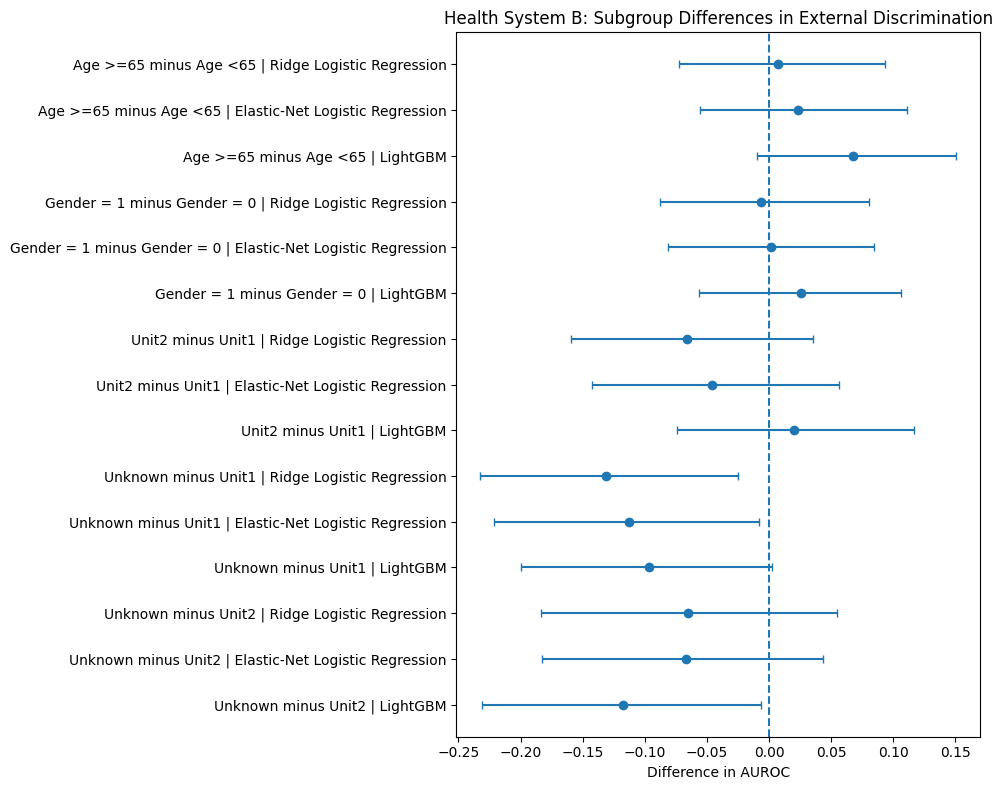

Saved subgroup AUROC contrast figure:
figures/system_b_subgroup_auroc_contrasts.png


In [14]:
import matplotlib.pyplot as plt


FIGURE_DIR = (
    ROOT
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SUBGROUP_CONTRAST_FIGURE_PATH = (
    FIGURE_DIR
    / "system_b_subgroup_auroc_contrasts.png"
)


contrast_plot_data = (
    subgroup_auroc_contrasts
    .copy()
)


contrast_plot_data[
    "label"
] = (
    contrast_plot_data[
        "contrast"
    ]
    +
    " | "
    +
    contrast_plot_data[
        "model"
    ]
)


contrast_plot_data = (
    contrast_plot_data
    .reset_index(
        drop=True
    )
)


y_positions = np.arange(
    len(
        contrast_plot_data
    )
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)


ax.errorbar(
    contrast_plot_data[
        "delta_AUROC"
    ],
    y_positions,
    xerr=[
        (
            contrast_plot_data[
                "delta_AUROC"
            ]
            -
            contrast_plot_data[
                "lower_95_ci"
            ]
        ),
        (
            contrast_plot_data[
                "upper_95_ci"
            ]
            -
            contrast_plot_data[
                "delta_AUROC"
            ]
        ),
    ],
    fmt="o",
    capsize=3,
)


ax.axvline(
    0,
    linestyle="--",
)


ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    contrast_plot_data[
        "label"
    ]
)


ax.set_xlabel(
    "Difference in AUROC"
)

ax.set_title(
    "Health System B: Subgroup Differences in External Discrimination"
)


ax.invert_yaxis()


plt.tight_layout()


fig.savefig(
    SUBGROUP_CONTRAST_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    f"Saved subgroup AUROC contrast figure:\n"
    f"{SUBGROUP_CONTRAST_FIGURE_PATH.relative_to(ROOT)}"
)

## 10. Subgroup Sensitivity Findings

External predictive performance is broadly stable across the primary
age and gender subgroup analyses.

### Age

No model shows clear evidence of an AUROC difference between patients
aged 65 years or older and those younger than 65 years.

LightGBM has a higher AUROC point estimate in the older subgroup, but
the bootstrap confidence interval for the direct contrast includes zero.

### Gender

External discrimination is similar across the two gender groups for all
three models.

Direct AUROC contrast intervals include zero, providing no clear
evidence of gender-specific discrimination differences.

### ICU-Unit Context

Performance heterogeneity is more apparent across ICU-unit context.

Unit1 and Unit2 do not show clear differences in AUROC.

In contrast, patients with unknown ICU-unit context generally show
poorer discrimination.

Relative to Unit1, the AUROC deficit for the Unknown group is supported
by bootstrap intervals for Ridge and elastic-net logistic regression.

LightGBM shows the same directional pattern, although the Unknown versus
Unit1 interval narrowly includes zero.

Relative to Unit2, LightGBM also shows lower discrimination in the
Unknown ICU-context group.

### Calibration

Calibration-in-the-large remains negative across all evaluated
subgroups and models, indicating that the systematic external
overprediction identified in the primary Health System B analysis is
not confined to a single demographic subgroup.

Calibration-slope estimates are less precise in the smaller ICU-context
groups.

The Unknown ICU-context group shows particularly weak calibration-slope
point estimates, but these estimates are interpreted cautiously because
of limited event counts.

### Overall Interpretation

The subgroup analysis does not identify clear demographic instability
by age or gender.

The strongest evidence of heterogeneous transportability instead occurs
across care-context documentation, particularly among patients whose ICU
unit is unknown in the frozen representation.

This pattern is consistent with the broader distribution-shift analysis,
which identified substantial cross-system differences in measurement and
recording processes.

These analyses are descriptive sensitivity analyses and do not establish
a causal relationship between ICU-context documentation and model
performance.

## 11. Save Subgroup Analysis Artifacts

Subgroup feasibility, point estimates, bootstrap uncertainty summaries,
and direct AUROC contrasts are saved as frozen analysis artifacts.

These outputs preserve the subgroup sensitivity results used for final
reporting.

In [15]:
TABLE_DIR = (
    ROOT
    / "results"
    / "frozen"
    / "tables"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


subgroup_feasibility.to_csv(
    TABLE_DIR
    / "system_b_subgroup_feasibility.csv",
    index=False,
)


subgroup_performance.to_csv(
    TABLE_DIR
    / "system_b_subgroup_performance.csv",
    index=False,
)


subgroup_bootstrap_summary.to_csv(
    TABLE_DIR
    / "system_b_subgroup_bootstrap_summary.csv",
    index=False,
)


subgroup_auroc_contrasts.to_csv(
    TABLE_DIR
    / "system_b_subgroup_auroc_contrasts.csv",
    index=False,
)


print(
    "Saved subgroup sensitivity analysis tables."
)

Saved subgroup sensitivity analysis tables.


## 12. Artifact Integrity Check

The saved subgroup analysis artifacts are checked for expected row
counts and completeness before the analysis is closed.

In [16]:
saved_subgroup_feasibility = pd.read_csv(
    TABLE_DIR
    / "system_b_subgroup_feasibility.csv"
)

saved_subgroup_performance = pd.read_csv(
    TABLE_DIR
    / "system_b_subgroup_performance.csv"
)

saved_subgroup_bootstrap = pd.read_csv(
    TABLE_DIR
    / "system_b_subgroup_bootstrap_summary.csv"
)

saved_subgroup_contrasts = pd.read_csv(
    TABLE_DIR
    / "system_b_subgroup_auroc_contrasts.csv"
)


artifact_integrity_summary = pd.Series(
    {
        "feasibility_rows":
            len(
                saved_subgroup_feasibility
            ),

        "performance_rows":
            len(
                saved_subgroup_performance
            ),

        "bootstrap_rows":
            len(
                saved_subgroup_bootstrap
            ),

        "contrast_rows":
            len(
                saved_subgroup_contrasts
            ),

        "missing_performance_values":
            int(
                saved_subgroup_performance
                .isna()
                .sum()
                .sum()
            ),

        "missing_bootstrap_values":
            int(
                saved_subgroup_bootstrap
                .isna()
                .sum()
                .sum()
            ),

        "missing_contrast_values":
            int(
                saved_subgroup_contrasts
                .isna()
                .sum()
                .sum()
            ),
    },
    name="Subgroup artifact integrity",
)


assert artifact_integrity_summary[
    "feasibility_rows"
] == 7

assert artifact_integrity_summary[
    "performance_rows"
] == 21

assert artifact_integrity_summary[
    "bootstrap_rows"
] == 84

assert artifact_integrity_summary[
    "contrast_rows"
] == 15

assert artifact_integrity_summary[
    "missing_performance_values"
] == 0

assert artifact_integrity_summary[
    "missing_bootstrap_values"
] == 0

assert artifact_integrity_summary[
    "missing_contrast_values"
] == 0


artifact_integrity_summary.to_frame()

,Subgroup artifact integrity
feasibility_rows,7
performance_rows,21
bootstrap_rows,84
contrast_rows,15
missing_performance_values,0
missing_bootstrap_values,0
missing_contrast_values,0


## 13. Final Status

**Health System B subgroup sensitivity analysis is complete.**

External discrimination is broadly stable across the evaluated age and
gender subgroups.

No clear AUROC difference is observed between Unit1 and Unit2.

The most consistent evidence of subgroup-specific degradation occurs
among patients with unknown ICU-unit context, where discrimination is
lower for multiple models and calibration-slope point estimates are also
weaker.

Systematic external overprediction remains present across all examined
subgroups, indicating that the overall calibration failure is not driven
by a single demographic population.

The subgroup findings are interpreted as sensitivity analyses rather
than confirmatory interaction tests, particularly because Health System B
contains only 175 events and ICU-context subgroups contain fewer events.

Across the evaluated stratifications, performance heterogeneity is more
apparent for the ICU-context proxy than for age or gender.

This pattern is consistent with the broader distribution-shift analysis,
which identified substantial cross-system differences in measurement
and recording processes, but the subgroup analysis does not establish a
causal relationship between documentation context and model
performance.

No subgroup result changes the frozen primary external-validation
analysis or the previously selected models.